# PCA aplicado a paquetes de Beyblade X

## Objetivo

Este notebook estudia si un conjunto de variables económicas, de contenido y de presencia competitiva puede resumirse mediante **Análisis de Componentes Principales (PCA)**.

El dataset de entrada fue construido previamente al combinar:

- precios y contenido de productos de Rucua;
- estadísticas competitivas de piezas obtenidas de Beywatch;
- escenarios de ingreso personal mensual;
- variables derivadas como `price_income_pct` y `price_per_bey`.

La unidad de análisis es **producto × escenario de ingreso**. Por ello, el mismo producto puede aparecer varias veces: sus características físicas y competitivas permanecen constantes, mientras cambia el contexto económico.

> **Importante:** PCA es una técnica no supervisada. No decide si “conviene comprar”; únicamente resume la estructura de las variables numéricas. Al final se incluye una extensión didáctica opcional para practicar clasificación con una etiqueta sintética y claramente identificada como tal.

## 1. Librerías y configuración

Se utilizan:

- `pandas` y `numpy` para manipulación numérica;
- `matplotlib` para visualizaciones;
- `StandardScaler` para estandarizar variables;
- `PCA` para reducción dimensional;
- `joblib` para guardar el escalador y el modelo PCA;
- herramientas de `scikit-learn` para la extensión supervisada opcional.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Carga del dataset

El archivo principal es `beyblade_pca_input.csv`. La notebook comprueba que exista antes de continuar para evitar errores poco claros.

También intenta leer `pca_candidate_features.json` si está disponible. Ese archivo funciona como registro de las variables candidatas generadas en la etapa de preparación de datos; el PCA final utilizará una selección depurada.

In [2]:
DATA_FILE = Path("beyblade_pca_input.csv")
FEATURES_FILE = Path("pca_candidate_features.json")
OUTPUT_DIR = Path("outputs_pca")
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "No se encontró 'beyblade_pca_input.csv'. "
        "Coloca este notebook en la misma carpeta que el CSV generado por la etapa de scraping/limpieza."
    )

dataset = pd.read_csv(DATA_FILE)

print("Dimensiones del dataset:", dataset.shape)
print("Productos únicos:", dataset["product_name"].nunique() if "product_name" in dataset.columns else "N/D")
print("Columnas:", len(dataset.columns))
display(dataset.head())


Dimensiones del dataset: (407, 41)
Productos únicos: 37
Columnas: 41


,source,product_name,product_type,brand,price,currency,stock_status,blade_count,ratchet_count,bit_count,launcher_count,stadium_count,bey_count,launcher_included,stadium_included,description_text,listing_url,snapshot_date,listing_id,product_code,ratchet,bit,blade,blade_match_status,composition_status,package_bey_count,package_usage_mean,package_usage_max,package_top_cuts_mean,package_top_cuts_max,package_first_rate_mean,package_first_rate_max,package_win_share_mean,package_win_share_max,package_match_coverage,package_meta_coverage,in_stock,scenario_id,ingreso_personal_mensual_mxn,price_income_pct,price_per_bey
0,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,4,0,4,1,0,BEYBLADE X es un gear sport que presenta batal...,https://rucua.com/products/bx-00-beyblade-25th...,2026-09-21,rucua_bx-00-beyblade-25th-anniversary-set,BX-00,NaN,NaN,NaN,multi_bey_set,multi_bey,4.0,5.55,46.5,536.083333,4488.0,28.308333,42.9,5.166667,45.5,1.0,1.0,0,LOW_01,4001,129.942514,1299.75
1,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,4,0,4,1,0,BEYBLADE X es un gear sport que presenta batal...,https://rucua.com/products/bx-00-beyblade-25th...,2026-09-21,rucua_bx-00-beyblade-25th-anniversary-set,BX-00,NaN,NaN,NaN,multi_bey_set,multi_bey,4.0,5.55,46.5,536.083333,4488.0,28.308333,42.9,5.166667,45.5,1.0,1.0,0,LOW_02,4500,115.533333,1299.75
2,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,4,0,4,1,0,BEYBLADE X es un gear sport que presenta batal...,https://rucua.com/products/bx-00-beyblade-25th...,2026-09-21,rucua_bx-00-beyblade-25th-anniversary-set,BX-00,NaN,NaN,NaN,multi_bey_set,multi_bey,4.0,5.55,46.5,536.083333,4488.0,28.308333,42.9,5.166667,45.5,1.0,1.0,0,LOW_03,5000,103.980000,1299.75
3,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,4,0,4,1,0,BEYBLADE X es un gear sport que presenta batal...,https://rucua.com/products/bx-00-beyblade-25th...,2026-09-21,rucua_bx-00-beyblade-25th-anniversary-set,BX-00,NaN,NaN,NaN,multi_bey_set,multi_bey,4.0,5.55,46.5,536.083333,4488.0,28.308333,42.9,5.166667,45.5,1.0,1.0,0,LOW_04,5500,94.527273,1299.75
4,Rucua,BX-00 Beyblade 25th Anniversary Set,Set,Takara Tomy,5199.0,MXN,OutOfStock,4,4,4,4,0,4,1,0,BEYBLADE X es un gear sport que presenta batal...,https://rucua.com/products/bx-00-beyblade-25th...,2026-09-21,rucua_bx-00-beyblade-25th-anniversary-set,BX-00,NaN,NaN,NaN,multi_bey_set,multi_bey,4.0,5.55,46.5,536.083333,4488.0,28.308333,42.9,5.166667,45.5,1.0,1.0,0,LOW_05,6000,86.650000,1299.75


In [3]:
if FEATURES_FILE.exists():
    with open(FEATURES_FILE, "r", encoding="utf-8") as archivo:
        features_candidatas = json.load(archivo)

    disponibles = [c for c in features_candidatas if c in dataset.columns]
    faltantes = [c for c in features_candidatas if c not in dataset.columns]

    print("Features candidatas disponibles:", len(disponibles))
    print("Features candidatas faltantes:", faltantes)
else:
    features_candidatas = []
    print("No se encontró pca_candidate_features.json; se utilizará la selección definida en este notebook.")


Features candidatas disponibles: 23
Features candidatas faltantes: []


## 3. Auditoría previa

Antes de aplicar PCA se revisan:

1. tipos de datos;
2. valores nulos;
3. valores infinitos;
4. duplicados exactos;
5. estadísticos descriptivos.

En la versión actual del proyecto se observaron 407 filas, sin nulos en las variables usadas para PCA y sin duplicados exactos en la matriz analítica.

No se eliminan valores altos de `price_income_pct` solo por ser extremos: un producto que supera el ingreso mensual de un escenario representa una situación económicamente difícil, pero válida para el análisis.

In [4]:
columnas_preliminares = [
    "price",
    "price_income_pct",
    "price_per_bey",
    "bey_count",
    "launcher_included",
    "stadium_included",
    "package_usage_mean",
    "package_usage_max",
    "package_top_cuts_mean",
    "package_top_cuts_max",
    "package_meta_coverage",
]

columnas_preliminares = [c for c in columnas_preliminares if c in dataset.columns]

X_preliminar = dataset[columnas_preliminares].copy()

print("Dimensiones de X preliminar:", X_preliminar.shape)
print("\nNulos:")
print(X_preliminar.isnull().sum())

print("\nInfinitos:")
print(np.isinf(X_preliminar.select_dtypes(include=np.number)).sum())

print("\nDuplicados exactos:", X_preliminar.duplicated().sum())

display(X_preliminar.describe().T)


Dimensiones de X preliminar: (407, 11)

Nulos:
price                    0
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_top_cuts_mean    0
package_top_cuts_max     0
package_meta_coverage    0
dtype: int64

Infinitos:
price                    0
price_income_pct         0
price_per_bey            0
bey_count                0
launcher_included        0
stadium_included         0
package_usage_mean       0
package_usage_max        0
package_top_cuts_mean    0
package_top_cuts_max     0
package_meta_coverage    0
dtype: int64

Duplicados exactos: 0


,count,mean,std,min,25%,50%,75%,max
price,407.0,1849.270270,1523.056842,599.000000,799.000000,1259.000000,1999.000000,6599.000000
price_income_pct,407.0,30.335627,27.028973,6.656295,12.096234,19.988235,36.832727,164.933767
price_per_bey,407.0,1715.074324,1432.154462,533.000000,799.000000,1099.000000,1999.000000,6599.000000
bey_count,407.0,1.135135,0.577850,1.000000,1.000000,1.000000,1.000000,4.000000
launcher_included,407.0,0.378378,0.485580,0.000000,0.000000,0.000000,1.000000,1.000000
stadium_included,407.0,0.027027,0.162362,0.000000,0.000000,0.000000,0.000000,1.000000
package_usage_mean,407.0,8.790691,9.798038,0.200000,1.933333,4.333333,12.966667,39.350000
package_usage_max,407.0,21.994595,23.015420,0.200000,2.900000,17.700000,29.100000,75.500000
package_top_cuts_mean,407.0,848.765015,946.562284,19.666667,186.333333,417.333333,1252.666667,3801.000000
package_top_cuts_max,407.0,2124.540541,2221.312136,23.000000,279.000000,1713.000000,2815.000000,7289.000000


## 4. Correlación y eliminación de redundancia

PCA puede trabajar con variables correlacionadas; de hecho, una de sus funciones es resumirlas. Sin embargo, si se incluyen varias transformaciones casi idénticas del mismo fenómeno, ese fenómeno puede quedar sobrerrepresentado.

En el análisis exploratorio se observaron correlaciones prácticamente perfectas entre:

- `package_usage_mean` y `package_top_cuts_mean`;
- `package_usage_max` y `package_top_cuts_max`.

También existía alta correlación entre `price`, `price_income_pct` y `price_per_bey`.

Por ello:

- se conservan `package_usage_mean` y `package_usage_max` como medidas competitivas más fáciles de interpretar;
- se conservan `price_income_pct` y `price_per_bey`;
- se excluye `price` del cálculo PCA, aunque permanece disponible en el dataset para interpretación.

Así se evita contar varias veces casi la misma señal.

In [5]:
correlaciones = X_preliminar.corr()

display(correlaciones.round(3))

pares_correlacionados = []

for i in range(len(correlaciones.columns)):
    for j in range(i + 1, len(correlaciones.columns)):
        valor = correlaciones.iloc[i, j]

        if abs(valor) >= 0.90:
            pares_correlacionados.append({
                "variable_1": correlaciones.columns[i],
                "variable_2": correlaciones.columns[j],
                "correlacion": valor
            })

df_correlaciones_altas = pd.DataFrame(pares_correlacionados)
display(df_correlaciones_altas)


,price,price_income_pct,price_per_bey,bey_count,launcher_included,stadium_included,package_usage_mean,package_usage_max,package_top_cuts_mean,package_top_cuts_max,package_meta_coverage
price,1.000,0.924,0.905,0.294,0.102,0.104,0.142,0.213,0.142,0.213,0.104
price_income_pct,0.924,1.000,0.836,0.272,0.095,0.096,0.131,0.197,0.132,0.197,0.096
price_per_bey,0.905,0.836,1.000,-0.118,0.030,0.126,0.186,0.152,0.186,0.152,0.089
bey_count,0.294,0.272,-0.118,1.000,0.107,-0.039,-0.094,0.132,-0.094,0.132,0.053
launcher_included,0.102,0.095,0.030,0.107,1.000,0.214,0.330,0.409,0.330,0.408,0.176
stadium_included,0.104,0.096,0.126,-0.039,0.214,1.000,0.143,0.178,0.143,0.178,0.038
package_usage_mean,0.142,0.131,0.186,-0.094,0.330,0.143,1.000,0.945,1.000,0.945,-0.103
package_usage_max,0.213,0.197,0.152,0.132,0.409,0.178,0.945,1.000,0.945,1.000,-0.033
package_top_cuts_mean,0.142,0.132,0.186,-0.094,0.330,0.143,1.000,0.945,1.000,0.945,-0.104
package_top_cuts_max,0.213,0.197,0.152,0.132,0.408,0.178,0.945,1.000,0.945,1.000,-0.033


,variable_1,variable_2,correlacion
0,price,price_income_pct,0.924356
1,price,price_per_bey,0.904549
2,package_usage_mean,package_usage_max,0.945438
3,package_usage_mean,package_top_cuts_mean,0.999999
4,package_usage_mean,package_top_cuts_max,0.945483
5,package_usage_max,package_top_cuts_mean,0.945423
6,package_usage_max,package_top_cuts_max,0.999999
7,package_top_cuts_mean,package_top_cuts_max,0.945468


## 5. Selección final de variables

Se utilizan ocho variables agrupadas en cuatro dimensiones conceptuales:

**Economía**
- `price_income_pct`: porcentaje del ingreso mensual que representa la compra.
- `price_per_bey`: costo del producto dividido entre la cantidad de Beyblades completos.

**Contenido**
- `bey_count`
- `launcher_included`
- `stadium_included`

**Presencia competitiva**
- `package_usage_mean`
- `package_usage_max`

**Calidad/cobertura del dato competitivo**
- `package_meta_coverage`

`package_meta_coverage` no representa que un producto sea “bueno”; indica qué proporción de las piezas pudo respaldarse con estadísticas competitivas.

In [6]:
features_pca_final = [
    "price_income_pct",
    "price_per_bey",
    "bey_count",
    "launcher_included",
    "stadium_included",
    "package_usage_mean",
    "package_usage_max",
    "package_meta_coverage",
]

faltantes_finales = [c for c in features_pca_final if c not in dataset.columns]

if faltantes_finales:
    raise KeyError(
        "Faltan columnas necesarias para el PCA final: "
        + ", ".join(faltantes_finales)
    )

X_final = dataset[features_pca_final].copy()

if X_final.isnull().any().any():
    raise ValueError(
        "X_final contiene NaN. Revisa la etapa de preparación antes de continuar."
    )

if np.isinf(X_final.to_numpy()).any():
    raise ValueError(
        "X_final contiene valores infinitos. Revisa la etapa de preparación antes de continuar."
    )

print("Dimensiones de X_final:", X_final.shape)
display(X_final.head())


Dimensiones de X_final: (407, 8)


,price_income_pct,price_per_bey,bey_count,launcher_included,stadium_included,package_usage_mean,package_usage_max,package_meta_coverage
0,129.942514,1299.75,4,1,0,5.55,46.5,1.0
1,115.533333,1299.75,4,1,0,5.55,46.5,1.0
2,103.980000,1299.75,4,1,0,5.55,46.5,1.0
3,94.527273,1299.75,4,1,0,5.55,46.5,1.0
4,86.650000,1299.75,4,1,0,5.55,46.5,1.0


## 6. Estandarización

PCA es sensible a la escala. Aquí conviven variables binarias (`0/1`), porcentajes y valores económicos, por lo que se aplica `StandardScaler`.

Para cada variable:

\[
z = \frac{x-\mu}{\sigma}
\]

Después de la transformación, cada variable tiene aproximadamente media 0 y desviación estándar 1. Esto evita que una variable domine el PCA solo por usar números más grandes.

In [7]:
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

chequeo_escalado = pd.DataFrame({
    "feature": features_pca_final,
    "media_escalada": X_final_scaled.mean(axis=0),
    "desviacion_escalada": X_final_scaled.std(axis=0),
})

display(chequeo_escalado)


,feature,media_escalada,desviacion_escalada
0,price_income_pct,6.546770e-17,1.0
1,price_per_bey,-1.134773e-16,1.0
2,bey_count,1.222064e-16,1.0
3,launcher_included,6.983221e-17,1.0
4,stadium_included,3.491610e-17,1.0
5,package_usage_mean,-1.396644e-16,1.0
6,package_usage_max,1.920386e-16,1.0
7,package_meta_coverage,-3.928062e-16,1.0


## 7. PCA exploratorio: ¿cuántos componentes conservar?

Primero se ajusta PCA sin limitar `n_components`. Así se observa cuánta varianza explica cada componente.

En la versión actual de los datos se obtuvo aproximadamente:

- 4 componentes → 80.0% de varianza acumulada;
- 5 componentes → 91.1%;
- 6 componentes → 98.7%.

Se utilizará como criterio automático el número mínimo de componentes necesario para alcanzar al menos **90% de varianza acumulada**. Con el dataset actual esto produce 5 componentes.

In [8]:
pca_exploratorio = PCA()
X_pca_exploratorio = pca_exploratorio.fit_transform(X_final_scaled)

varianza = pca_exploratorio.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

tabla_varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza))],
    "Varianza_explicada_pct": varianza * 100,
    "Varianza_acumulada_pct": varianza_acumulada * 100,
})

display(tabla_varianza.round(3))


,Componente,Varianza_explicada_pct,Varianza_acumulada_pct
0,PC1,30.930,30.930
1,PC2,20.696,51.626
2,PC3,14.953,66.579
3,PC4,13.433,80.012
4,PC5,11.088,91.100
5,PC6,7.596,98.696
6,PC7,1.000,99.696
7,PC8,0.304,100.000


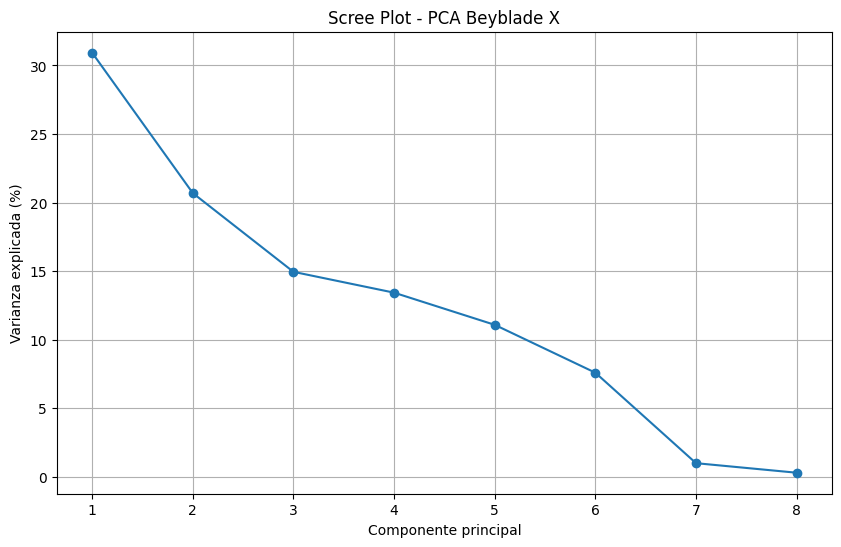

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(varianza) + 1),
    varianza * 100,
    marker="o"
)
plt.xlabel("Componente principal")
plt.ylabel("Varianza explicada (%)")
plt.title("Scree Plot - PCA Beyblade X")
plt.xticks(range(1, len(varianza) + 1))
plt.grid()
plt.show()


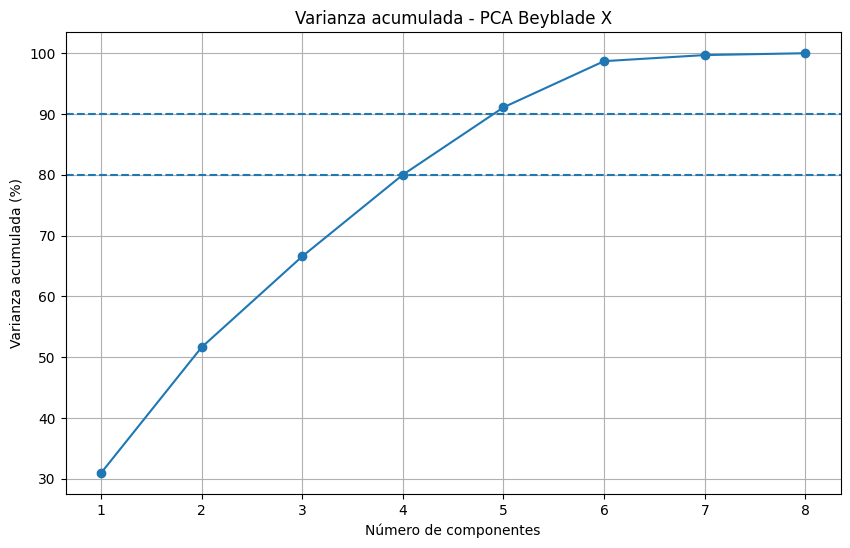

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada * 100,
    marker="o"
)
plt.axhline(80, linestyle="--")
plt.axhline(90, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.title("Varianza acumulada - PCA Beyblade X")
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid()
plt.show()


In [11]:
for limite in [0.80, 0.90, 0.95]:
    n = int(np.argmax(varianza_acumulada >= limite) + 1)
    print(f"{int(limite * 100)}% -> {n} componentes")

N_COMPONENTS = int(np.argmax(varianza_acumulada >= 0.90) + 1)

print("\nComponentes seleccionados:", N_COMPONENTS)
print(
    "Varianza acumulada conservada:",
    f"{varianza_acumulada[N_COMPONENTS - 1] * 100:.2f}%"
)


80% -> 4 componentes
90% -> 5 componentes
95% -> 6 componentes

Componentes seleccionados: 5
Varianza acumulada conservada: 91.10%


## 8. PCA final

Se vuelve a ajustar PCA usando únicamente el número de componentes seleccionado.

Cada fila se transforma de ocho variables originales a un conjunto reducido de componentes (`PC1`, `PC2`, ...). Los componentes son combinaciones lineales ortogonales entre sí.

> **Nota importante sobre el signo:** en PCA el signo de un componente puede invertirse sin cambiar su significado matemático. Por eso se interpreta principalmente qué variables tienen mayor magnitud absoluta y qué variables se mueven juntas o en sentido contrario.

In [12]:
pca_final = PCA(n_components=N_COMPONENTS)
X_pca_final = pca_final.fit_transform(X_final_scaled)

nombres_pc = [f"PC{i+1}" for i in range(N_COMPONENTS)]

df_componentes_final = pd.DataFrame(
    X_pca_final,
    columns=nombres_pc,
    index=dataset.index
)

display(df_componentes_final.head())


,PC1,PC2,PC3,PC4,PC5
0,2.475254,2.108708,3.780164,3.587212,1.380218
1,2.275888,1.792264,3.785465,3.499434,1.351609
2,2.116036,1.538539,3.789715,3.429052,1.328670
3,1.985247,1.330945,3.793192,3.371467,1.309902
4,1.876257,1.157950,3.796090,3.323480,1.294263


## 9. Loadings: qué significa cada componente

Los **loadings** indican cuánto participa cada variable original en cada componente.

Con el dataset actual se observó:

- **PC1:** dominado por `package_usage_max` y `package_usage_mean`, con contribuciones económicas y de launcher. Se interpreta como una dimensión de **intensidad competitiva/comercial**.
- **PC2:** `price_income_pct` y `price_per_bey` son positivos, mientras que las variables de uso competitivo son negativas. Se interpreta como un **contraste entre presión económica y presencia competitiva**.
- **PC3:** destacan `bey_count`, `package_meta_coverage` y `launcher_included`; representa principalmente **contenido y completitud/cobertura del paquete**.
- **PC4:** contrasta `bey_count` frente a `stadium_included` y `package_meta_coverage`; describe diferencias en la **estructura del tipo de paquete**.
- **PC5:** está fuertemente asociado a `stadium_included` y en sentido opuesto a `package_meta_coverage`; captura sobre todo el caso particular de **productos con estadio**.

Estas etiquetas son interpretaciones descriptivas, no puntuaciones de “bueno/malo”.

In [13]:
loadings_final = pd.DataFrame(
    pca_final.components_.T,
    index=features_pca_final,
    columns=nombres_pc
)

display(loadings_final.round(3))


,PC1,PC2,PC3,PC4,PC5
price_income_pct,0.374,0.593,-0.010,0.164,0.054
price_per_bey,0.355,0.569,-0.279,-0.104,-0.076
bey_count,0.077,0.110,0.611,0.620,0.301
launcher_included,0.340,-0.214,0.428,-0.213,-0.028
stadium_included,0.219,-0.035,0.076,-0.542,0.760
package_usage_mean,0.516,-0.353,-0.225,0.088,-0.178
package_usage_max,0.544,-0.328,-0.030,0.174,-0.104
package_meta_coverage,0.047,0.185,0.556,-0.448,-0.529


In [14]:
for pc in nombres_pc:
    importancia = (
        loadings_final[pc]
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame(name="loading")
    )

    print("\n" + "=" * 60)
    print(pc)
    print("=" * 60)
    display(importancia)



PC1


,loading
package_usage_max,0.544049
package_usage_mean,0.516146
price_income_pct,0.373514
price_per_bey,0.355329
launcher_included,0.340439
stadium_included,0.218788
bey_count,0.076704
package_meta_coverage,0.046713



PC2


,loading
price_income_pct,0.592860
price_per_bey,0.568878
package_usage_mean,-0.352561
package_usage_max,-0.327934
launcher_included,-0.213569
package_meta_coverage,0.184875
bey_count,0.109876
stadium_included,-0.034516



PC3


,loading
bey_count,0.610714
package_meta_coverage,0.555568
launcher_included,0.427844
price_per_bey,-0.279315
package_usage_mean,-0.224792
stadium_included,0.076131
package_usage_max,-0.029637
price_income_pct,-0.009930



PC4


,loading
bey_count,0.620115
stadium_included,-0.542088
package_meta_coverage,-0.447626
launcher_included,-0.213159
package_usage_max,0.173826
price_income_pct,0.164454
price_per_bey,-0.103861
package_usage_mean,0.088005



PC5


,loading
stadium_included,0.760446
package_meta_coverage,-0.528506
bey_count,0.300970
package_usage_mean,-0.177646
package_usage_max,-0.103768
price_per_bey,-0.076462
price_income_pct,0.053599
launcher_included,-0.027843


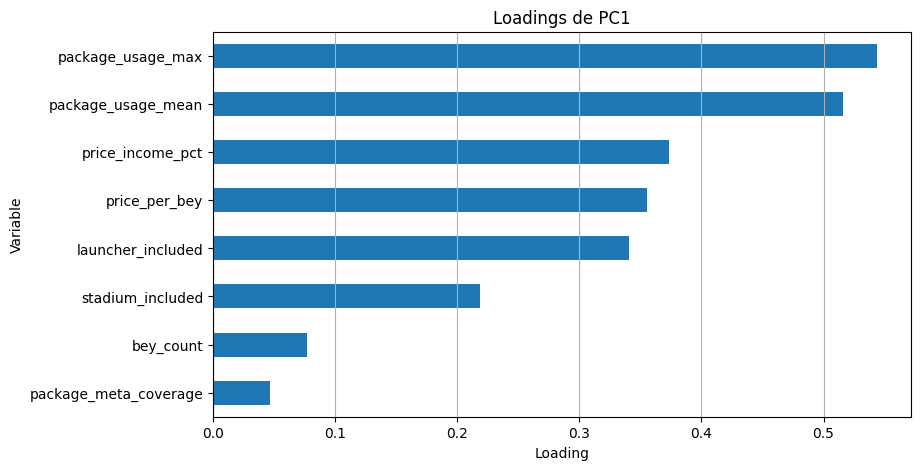

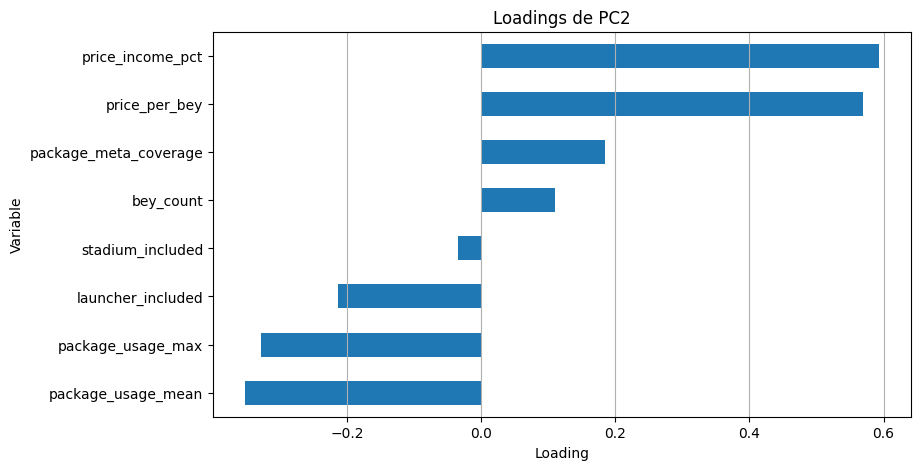

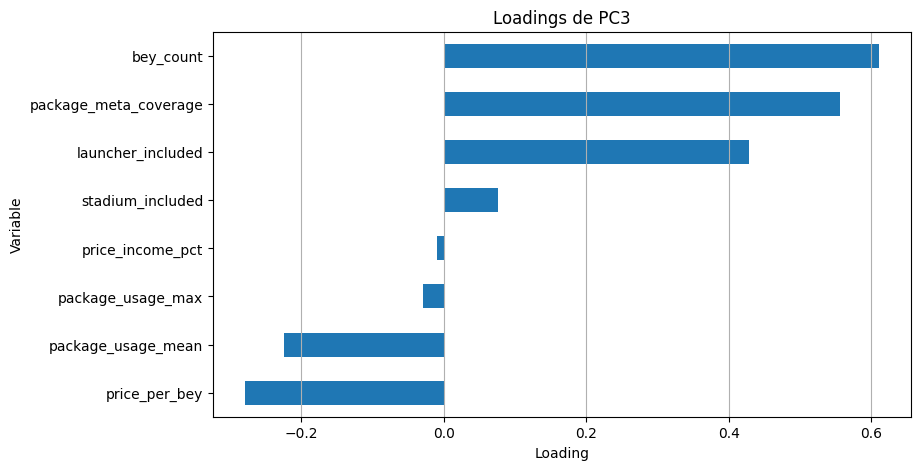

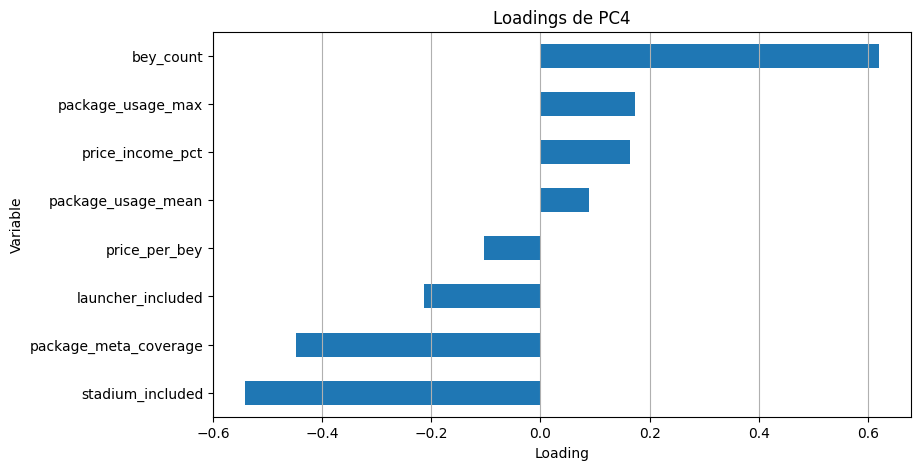

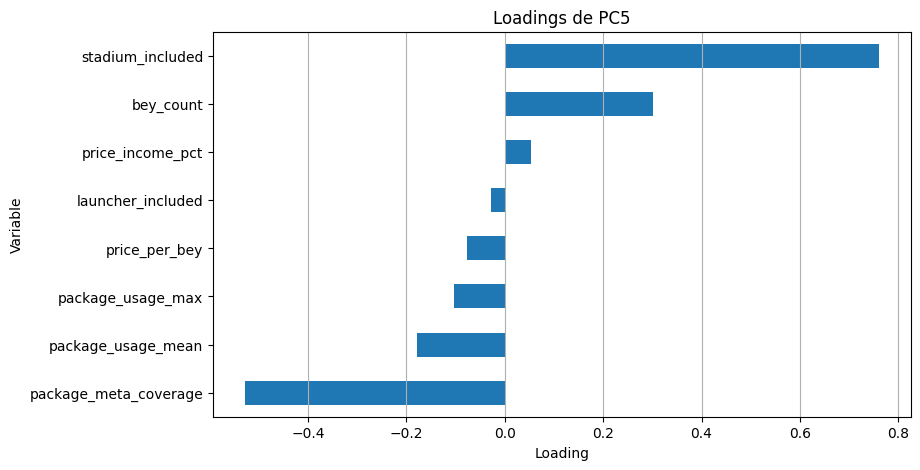

In [15]:
for pc in nombres_pc:
    plt.figure(figsize=(9, 5))
    loadings_final[pc].sort_values().plot(kind="barh")
    plt.title(f"Loadings de {pc}")
    plt.xlabel("Loading")
    plt.ylabel("Variable")
    plt.grid(axis="x")
    plt.show()


## 10. Dataset de resultados PCA

Se conservan identificadores y variables originales para interpretar las coordenadas PCA.

Las columnas `PC1...PCn` son los **scores**: la posición de cada observación en el nuevo espacio reducido.

In [16]:
columnas_contexto = [
    c for c in [
        "listing_id",
        "product_name",
        "product_type",
        "scenario_id",
        "ingreso_personal_mensual_mxn",
        "price",
        "price_income_pct",
        "price_per_bey",
        "package_usage_mean",
        "package_usage_max",
    ]
    if c in dataset.columns
]

df_resultado_pca = pd.concat(
    [
        dataset[columnas_contexto].reset_index(drop=True),
        df_componentes_final.reset_index(drop=True),
    ],
    axis=1
)

display(df_resultado_pca.head(20))


,listing_id,product_name,product_type,scenario_id,ingreso_personal_mensual_mxn,price,price_income_pct,price_per_bey,package_usage_mean,package_usage_max,PC1,PC2,PC3,PC4,PC5
0,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_01,4001,5199.0,129.942514,1299.75,5.550000,46.5,2.475254,2.108708,3.780164,3.587212,1.380218
1,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_02,4500,5199.0,115.533333,1299.75,5.550000,46.5,2.275888,1.792264,3.785465,3.499434,1.351609
2,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_03,5000,5199.0,103.980000,1299.75,5.550000,46.5,2.116036,1.538539,3.789715,3.429052,1.328670
3,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_04,5500,5199.0,94.527273,1299.75,5.550000,46.5,1.985247,1.330945,3.793192,3.371467,1.309902
4,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_05,6000,5199.0,86.650000,1299.75,5.550000,46.5,1.876257,1.157950,3.796090,3.323480,1.294263
5,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_06,6500,5199.0,79.984615,1299.75,5.550000,46.5,1.784035,1.011570,3.798542,3.282876,1.281029
6,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_07,7000,5199.0,74.271429,1299.75,5.550000,46.5,1.704987,0.886101,3.800643,3.248072,1.269685
7,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_08,7500,5199.0,69.320000,1299.75,5.550000,46.5,1.636478,0.777362,3.802464,3.217908,1.259855
8,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_09,8000,5199.0,64.987500,1299.75,5.550000,46.5,1.576534,0.682215,3.804058,3.191515,1.251253
9,rucua_bx-00-beyblade-25th-anniversary-set,BX-00 Beyblade 25th Anniversary Set,Set,LOW_10,8500,5199.0,61.164706,1299.75,5.550000,46.5,1.523641,0.598261,3.805464,3.168227,1.243663


## 11. Visualización PC1 vs PC2

La gráfica permite observar la estructura de los productos y escenarios económicos en dos dimensiones.

Los pequeños segmentos o trayectorias no son duplicados: cada producto aparece bajo varios escenarios de ingreso. Sus características competitivas se mantienen, pero `price_income_pct` cambia, desplazando su posición en el espacio PCA.

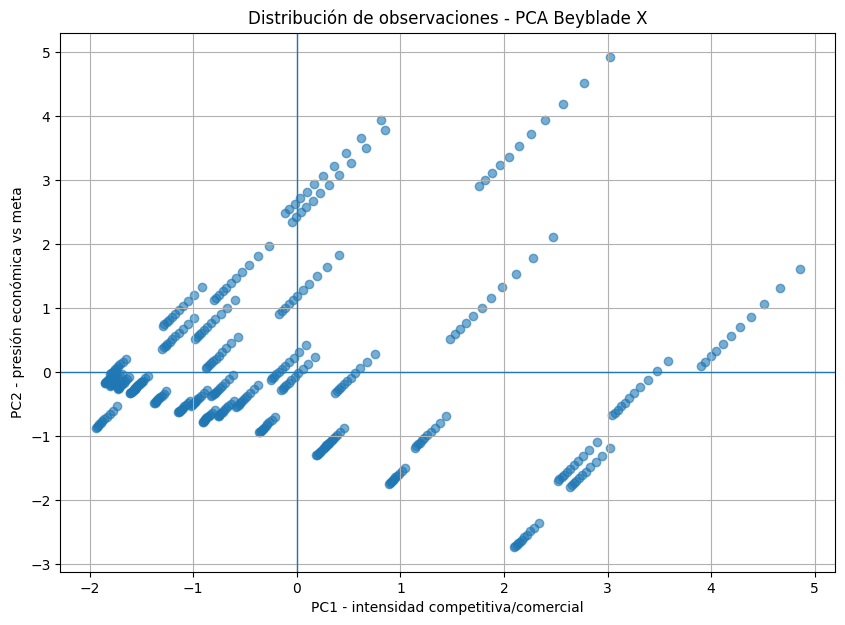

In [17]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_resultado_pca["PC1"],
    df_resultado_pca["PC2"],
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1 - intensidad competitiva/comercial")
plt.ylabel("PC2 - presión económica vs meta")
plt.title("Distribución de observaciones - PCA Beyblade X")
plt.grid()
plt.show()


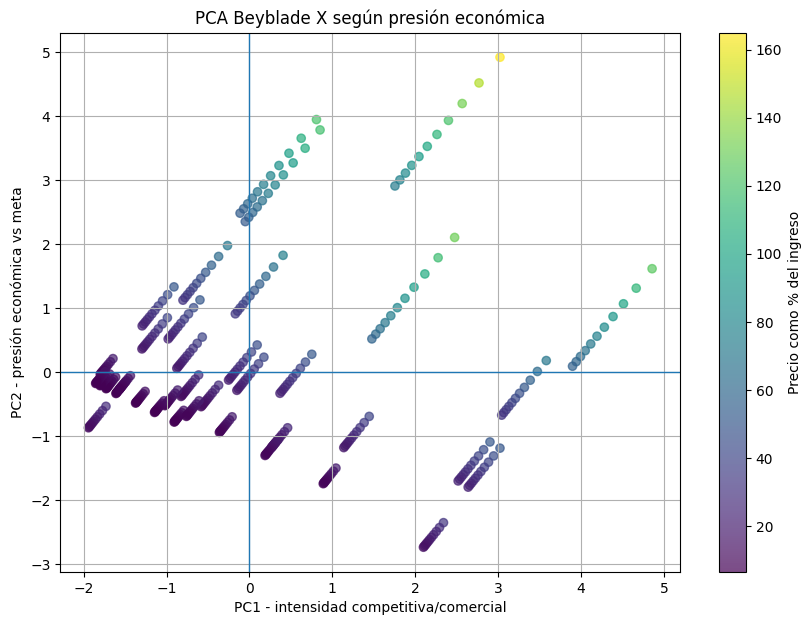

In [18]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_resultado_pca["PC1"],
    df_resultado_pca["PC2"],
    c=df_resultado_pca["price_income_pct"],
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Precio como % del ingreso"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1 - intensidad competitiva/comercial")
plt.ylabel("PC2 - presión económica vs meta")
plt.title("PCA Beyblade X según presión económica")
plt.grid()
plt.show()


## 12. Trayectoria de un mismo producto al cambiar el ingreso

Esta visualización mantiene constante el producto y cambia únicamente el escenario de ingreso.

Sirve para observar una idea central del proyecto: **el valor competitivo de un Beyblade no cambia porque cambie el ingreso del comprador, pero su presión económica sí**.

El código selecciona Dran Sword si existe; de lo contrario toma automáticamente el primer producto disponible para que `Run All` no falle.

In [19]:
producto_preferido = "BX-00 Booster Dran Sword 3-60F Version 2.0"

productos_disponibles = dataset["product_name"].dropna().drop_duplicates().tolist()

if producto_preferido in productos_disponibles:
    producto_ejemplo = producto_preferido
else:
    producto_ejemplo = productos_disponibles[0]

trayectoria = (
    df_resultado_pca[
        df_resultado_pca["product_name"] == producto_ejemplo
    ]
    .sort_values("ingreso_personal_mensual_mxn")
    .copy()
)

display(
    trayectoria[
        [
            c for c in [
                "product_name",
                "ingreso_personal_mensual_mxn",
                "price",
                "price_income_pct",
                "PC1",
                "PC2",
            ]
            if c in trayectoria.columns
        ]
    ]
)


,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC1,PC2
55,BX-00 Booster Dran Sword 3-60F Version 2.0,4001,999.0,24.968758,0.460153,-0.865550
56,BX-00 Booster Dran Sword 3-60F Version 2.0,4500,999.0,22.200000,0.421845,-0.926356
57,BX-00 Booster Dran Sword 3-60F Version 2.0,5000,999.0,19.980000,0.391129,-0.975110
58,BX-00 Booster Dran Sword 3-60F Version 2.0,5500,999.0,18.163636,0.365997,-1.014999
59,BX-00 Booster Dran Sword 3-60F Version 2.0,6000,999.0,16.650000,0.345055,-1.048241
60,BX-00 Booster Dran Sword 3-60F Version 2.0,6500,999.0,15.369231,0.327334,-1.076368
61,BX-00 Booster Dran Sword 3-60F Version 2.0,7000,999.0,14.271429,0.312144,-1.100477
62,BX-00 Booster Dran Sword 3-60F Version 2.0,7500,999.0,13.320000,0.298980,-1.121372
63,BX-00 Booster Dran Sword 3-60F Version 2.0,8000,999.0,12.487500,0.287462,-1.139654
64,BX-00 Booster Dran Sword 3-60F Version 2.0,8500,999.0,11.752941,0.277299,-1.155786


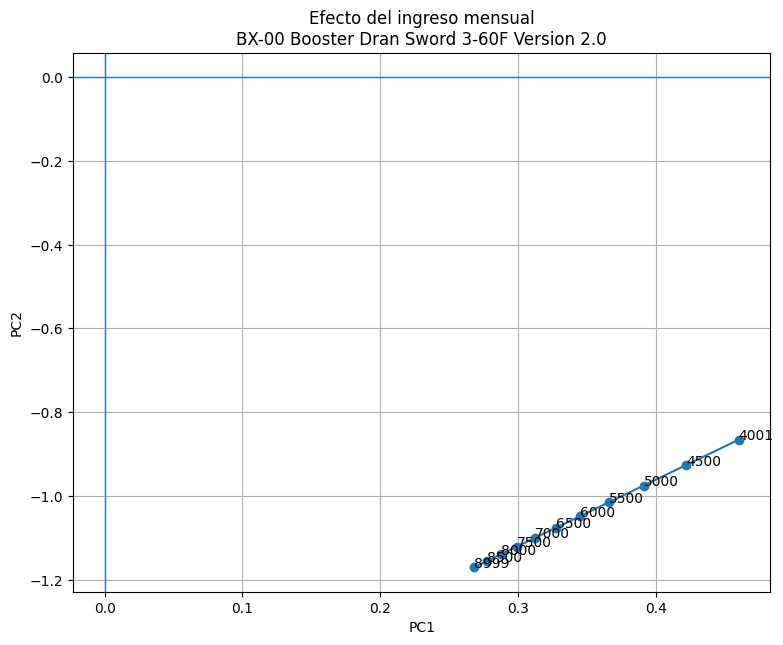

In [20]:
plt.figure(figsize=(9, 7))

plt.plot(
    trayectoria["PC1"],
    trayectoria["PC2"],
    marker="o"
)

for _, fila in trayectoria.iterrows():
    if "ingreso_personal_mensual_mxn" in fila.index:
        plt.annotate(
            int(fila["ingreso_personal_mensual_mxn"]),
            (fila["PC1"], fila["PC2"])
        )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Efecto del ingreso mensual\n{producto_ejemplo}")
plt.grid()
plt.show()


## 13. Observaciones extremas

Los extremos ayudan a comprobar que la interpretación de los componentes coincide con casos reales del dataset.

No se consideran automáticamente “mejores” o “peores”; solo son observaciones con scores altos o bajos en una dimensión PCA.

In [21]:
for pc in ["PC1", "PC2"]:
    columnas_mostrar = [
        c for c in [
            "product_name",
            "ingreso_personal_mensual_mxn",
            "price",
            "price_income_pct",
            pc,
        ]
        if c in df_resultado_pca.columns
    ]

    print(f"\nTop 5 de {pc}:")
    display(df_resultado_pca.nlargest(5, pc)[columnas_mostrar])

    print(f"Bottom 5 de {pc}:")
    display(df_resultado_pca.nsmallest(5, pc)[columnas_mostrar])



Top 5 de PC1:


,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC1
264,BX-00 Starter Phoenix Wing 9-60GF Metal Coat: ...,4001,4999.0,124.943764,4.857758
265,BX-00 Starter Phoenix Wing 9-60GF Metal Coat: ...,4500,4999.0,111.088889,4.666062
266,BX-00 Starter Phoenix Wing 9-60GF Metal Coat: ...,5000,4999.0,99.980000,4.512359
267,BX-00 Starter Phoenix Wing 9-60GF Metal Coat: ...,5500,4999.0,90.890909,4.386602
268,BX-00 Starter Phoenix Wing 9-60GF Metal Coat: ...,6000,4999.0,83.316667,4.281804


Bottom 5 de PC1:


,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC1
142,BX-00 Booster Mammoth Task Metal Coat: Black,8999,1099.0,12.212468,-1.942750
141,BX-00 Booster Mammoth Task Metal Coat: Black,8500,1099.0,12.929412,-1.932830
140,BX-00 Booster Mammoth Task Metal Coat: Black,8000,1099.0,13.737500,-1.921650
139,BX-00 Booster Mammoth Task Metal Coat: Black,7500,1099.0,14.653333,-1.908978
138,BX-00 Booster Mammoth Task Metal Coat: Black,7000,1099.0,15.700000,-1.894496



Top 5 de PC2:


,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC2
198,BX-00 CoroCoro Phoenix Wing 9-80DB Metal Coat:...,4001,6599.0,164.933767,4.925025
199,BX-00 CoroCoro Phoenix Wing 9-80DB Metal Coat:...,4500,6599.0,146.644444,4.523369
200,BX-00 CoroCoro Phoenix Wing 9-80DB Metal Coat:...,5000,6599.0,131.980000,4.201319
231,BX-00 G3 Tournament Prize Knight Shield 3-80N ...,4001,4799.0,119.945014,3.950912
201,BX-00 CoroCoro Phoenix Wing 9-80DB Metal Coat:...,5500,6599.0,119.981818,3.937824


Bottom 5 de PC2:


,product_name,ingreso_personal_mensual_mxn,price,price_income_pct,PC2
252,BX-00 Random Booster Lightning L drago 1-60F,8999,1259.0,13.990443,-2.731772
251,BX-00 Random Booster Lightning L drago 1-60F,8500,1259.0,14.811765,-2.713734
250,BX-00 Random Booster Lightning L drago 1-60F,8000,1259.0,15.737500,-2.693404
249,BX-00 Random Booster Lightning L drago 1-60F,7500,1259.0,16.786667,-2.670363
248,BX-00 Random Booster Lightning L drago 1-60F,7000,1259.0,17.985714,-2.644031


## 14. Comprobación de reconstrucción

PCA reduce dimensionalidad, por lo que existe pérdida de información. Se puede medir reconstruyendo las variables estandarizadas desde los componentes retenidos.

El error cuadrático medio de reconstrucción (`MSE`) no es una métrica de clasificación; únicamente resume cuánto detalle se pierde al reducir de 8 variables a los componentes seleccionados.

In [22]:
X_reconstruido = pca_final.inverse_transform(X_pca_final)

mse_reconstruccion = np.mean(
    (X_final_scaled - X_reconstruido) ** 2
)

print("MSE de reconstrucción:", round(float(mse_reconstruccion), 6))
print(
    "Varianza conservada:",
    f"{pca_final.explained_variance_ratio_.sum() * 100:.2f}%"
)


MSE de reconstrucción: 0.088996
Varianza conservada: 91.10%


# 15. Extensión didáctica: clasificación de compra

Esta sección es **opcional** y tiene un propósito educativo.

No existe en este dataset una etiqueta observada de comportamiento real de compra. Por ello se construye una variable llamada `compra_demo` a partir de una regla transparente y reproducible.

**No debe interpretarse como verdad de mercado ni como recomendación real.** El objetivo es practicar el flujo:

\[
\text{variables originales} \rightarrow \text{PCA} \rightarrow \text{clasificador}
\]

La regla usa rankings relativos del propio dataset para combinar:

- asequibilidad (`price_income_pct`);
- costo por Bey (`price_per_bey`);
- presencia competitiva (`package_usage_mean` y `package_usage_max`);
- contenido adicional (`bey_count`, launcher y estadio).

Después se entrena una regresión logística usando únicamente los componentes PCA para comprobar cuánto de esa regla puede recuperarse desde el espacio reducido.

In [23]:
# Rankings entre 0 y 1.
# En costo, un valor menor recibe mejor puntuación.
affordability_score = 1 - dataset["price_income_pct"].rank(pct=True)
unit_value_score = 1 - dataset["price_per_bey"].rank(pct=True)

competitive_score = (
    dataset["package_usage_mean"].rank(pct=True)
    + dataset["package_usage_max"].rank(pct=True)
) / 2

content_score = (
    dataset["bey_count"].rank(pct=True)
    + dataset["launcher_included"].astype(float)
    + dataset["stadium_included"].astype(float)
) / 3

dataset_demo = dataset.copy()

dataset_demo["score_compra_demo"] = (
    0.40 * affordability_score
    + 0.35 * competitive_score
    + 0.15 * unit_value_score
    + 0.10 * content_score
)

umbral_demo = dataset_demo["score_compra_demo"].median()

dataset_demo["compra_demo"] = (
    dataset_demo["score_compra_demo"] >= umbral_demo
).astype(int)

print("Umbral sintético:", round(float(umbral_demo), 4))
print("\nDistribución de compra_demo:")
print(dataset_demo["compra_demo"].value_counts())
print("\nProporciones:")
print(dataset_demo["compra_demo"].value_counts(normalize=True).round(3))


Umbral sintético: 0.5021

Distribución de compra_demo:
compra_demo
1    204
0    203
Name: count, dtype: int64

Proporciones:
compra_demo
1    0.501
0    0.499
Name: proportion, dtype: float64


### División train/test sin fuga por producto

Como el mismo producto aparece bajo varios escenarios de ingreso, un `train_test_split` aleatorio por filas permitiría que el mismo producto apareciera tanto en entrenamiento como en prueba.

Para reducir esa fuga se divide por **grupo de producto** (`listing_id` cuando existe; si no, `product_name`). De esta manera, los productos del conjunto de prueba no aparecen en el entrenamiento.

In [24]:
grupo_col = "listing_id" if "listing_id" in dataset_demo.columns else "product_name"
grupos = dataset_demo[grupo_col].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df_componentes_final,
        dataset_demo["compra_demo"],
        groups=grupos
    )
)

X_train = df_componentes_final.iloc[train_idx]
X_test = df_componentes_final.iloc[test_idx]

y_train = dataset_demo["compra_demo"].iloc[train_idx]
y_test = dataset_demo["compra_demo"].iloc[test_idx]

print("Filas train:", len(train_idx))
print("Filas test:", len(test_idx))
print("Productos/grupos train:", grupos.iloc[train_idx].nunique())
print("Productos/grupos test:", grupos.iloc[test_idx].nunique())


Filas train: 297
Filas test: 110
Productos/grupos train: 27
Productos/grupos test: 10


### Regresión logística

La regresión logística recibe como entradas los componentes PCA, no las ocho variables originales.

La evaluación incluye:

- `accuracy`;
- `F1`;
- `ROC-AUC`;
- matriz de confusión;
- reporte por clase.

Dado que `compra_demo` fue creada con una regla artificial, una buena métrica solo indica que los componentes PCA conservan suficiente información para aproximar esa regla. **No valida comportamiento real de compradores.**

In [25]:
modelo_logistico = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

modelo_logistico.fit(X_train, y_train)

pred = modelo_logistico.predict(X_test)
prob = modelo_logistico.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc_auc = roc_auc_score(y_test, prob) if y_test.nunique() == 2 else np.nan

print("Accuracy:", round(accuracy, 3))
print("F1:", round(f1, 3))
print("ROC-AUC:", round(float(roc_auc), 3) if not np.isnan(roc_auc) else "N/D")
print("\nReporte de clasificación:")
print(classification_report(y_test, pred, digits=3))


Accuracy: 0.764
F1: 0.794
ROC-AUC: 0.943

Reporte de clasificación:
              precision    recall  f1-score   support

           0      1.000     0.567     0.723        60
           1      0.658     1.000     0.794        50

    accuracy                          0.764       110
   macro avg      0.829     0.783     0.759       110
weighted avg      0.844     0.764     0.755       110



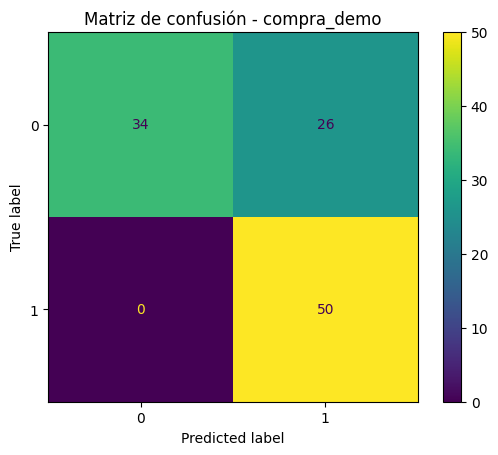

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.title("Matriz de confusión - compra_demo")
plt.show()


In [27]:
coeficientes_logistica = pd.DataFrame({
    "Componente": nombres_pc,
    "Coeficiente": modelo_logistico.coef_[0],
}).sort_values(
    "Coeficiente",
    key=lambda s: s.abs(),
    ascending=False
)

display(coeficientes_logistica)


,Componente,Coeficiente
1,PC2,-4.113147
0,PC1,-1.123683
2,PC3,1.114053
3,PC4,-0.523087
4,PC5,-0.222316


## 16. Qué sí y qué no demuestra la clasificación

Este bloque permite practicar una pipeline supervisada, pero tiene límites claros:

- `compra_demo` fue construida a partir de una regla, no observada en personas reales;
- por lo tanto, el modelo aprende a aproximar esa regla;
- una métrica alta no demuestra que prediga decisiones reales de compra;
- para un modelo de comportamiento real se necesitarían etiquetas obtenidas de compras, encuestas o experimentos;
- la división por producto evita una parte importante de la fuga de datos entre escenarios.

Para un reporte académico, conviene separar claramente los resultados **descriptivos del PCA** de esta **extensión sintética de clasificación**.

# 17. Exportación y reproducibilidad

Se guardan:

- scores PCA por observación;
- loadings;
- varianza explicada;
- lista de features;
- escalador;
- modelo PCA;
- resultados de la extensión didáctica.

Esto permite reutilizar exactamente la misma transformación sin volver a ajustar PCA.

In [28]:
# Resultados PCA
df_resultado_pca.to_csv(
    OUTPUT_DIR / "beyblade_pca_resultados.csv",
    index=False,
    encoding="utf-8-sig"
)

loadings_final.to_csv(
    OUTPUT_DIR / "beyblade_pca_loadings.csv",
    encoding="utf-8-sig"
)

tabla_varianza.to_csv(
    OUTPUT_DIR / "beyblade_pca_varianza.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    OUTPUT_DIR / "pca_features_final.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        features_pca_final,
        f,
        ensure_ascii=False,
        indent=2
    )

joblib.dump(
    scaler_final,
    OUTPUT_DIR / "pca_scaler_final.joblib"
)

joblib.dump(
    pca_final,
    OUTPUT_DIR / "pca_model_final.joblib"
)

# Extensión didáctica
resultados_demo = pd.concat(
    [
        dataset_demo[
            [
                c for c in [
                    "listing_id",
                    "product_name",
                    "scenario_id",
                    "score_compra_demo",
                    "compra_demo",
                ]
                if c in dataset_demo.columns
            ]
        ].reset_index(drop=True),
        df_componentes_final.reset_index(drop=True),
    ],
    axis=1
)

resultados_demo.to_csv(
    OUTPUT_DIR / "beyblade_compra_demo.csv",
    index=False,
    encoding="utf-8-sig"
)

joblib.dump(
    modelo_logistico,
    OUTPUT_DIR / "logistic_compra_demo.joblib"
)

print("Archivos guardados en:", OUTPUT_DIR.resolve())


Archivos guardados en: C:\Users\tr4nvo Bv\OneDrive\Escritorio\Practicas-CD\prueba1\outputs_pca


# 18. Conclusiones del ejercicio

Con la versión actual de los datos:

1. La auditoría mostró que varias variables iniciales eran redundantes, especialmente `usage` y `top_cuts`.
2. El PCA final se calculó sobre 8 variables depuradas.
3. Con 5 componentes se conservó aproximadamente **91.1% de la varianza**, reduciendo la dimensionalidad sin perder la mayor parte de la información.
4. Los componentes separaron dimensiones relacionadas con competitividad, presión económica y estructura del paquete.
5. La visualización por ingreso mostró que un mismo producto puede desplazarse en el espacio PCA al cambiar el contexto económico, aunque su contenido y valor competitivo permanezcan constantes.
6. PCA debe interpretarse como herramienta descriptiva y de compresión, no como una regla automática de compra.
7. La regresión logística incluida al final es una práctica supervisada sobre una etiqueta sintética; no sustituye datos reales de comportamiento del consumidor.

## Limitaciones

- Los precios representan snapshots de las fuentes disponibles y pueden cambiar.
- Las métricas de Beywatch también son temporales y dependen del meta competitivo observado.
- Los escenarios de ingreso fueron construidos para modelado y no representan 407 compradores independientes.
- Varias observaciones corresponden al mismo producto bajo distintos ingresos.
- La fuente de precios todavía puede enriquecerse con Amazon y fuentes japonesas.
- Una recomendación real requeriría preferencias del usuario, presupuesto disponible, piezas ya poseídas, disponibilidad y etiquetas reales de compra.

El notebook queda preparado para repetir el análisis cuando el dataset sea actualizado con nuevas fuentes o nuevos productos.